In [361]:
import pandas as pd

In [362]:
df=pd.read_csv('Indian Liver Patient Dataset (ILPD).csv')

In [363]:
df.head()

,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.9,1
0,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
1,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
2,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
3,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
4,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1


The data is unstructured 
Giving it column names for the features

In [364]:
df.columns=['Age','Gender','TB','DB','Alkphos','Sgpt','Sgot','TP','ALB','A/G Ratio','Target']

In [365]:
df.head(20)

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
1,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
2,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
3,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
4,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1
5,26,Female,0.9,0.2,154,16,12,7.0,3.5,1.00,1
6,29,Female,0.9,0.3,202,14,11,6.7,3.6,1.10,1
7,17,Male,0.9,0.3,202,22,19,7.4,4.1,1.20,2
8,55,Male,0.7,0.2,290,53,58,6.8,3.4,1.00,1
9,57,Male,0.6,0.1,210,51,59,5.9,2.7,0.80,1


Dimensions of Data

In [366]:
df.shape

(582, 11)

In [367]:

df.dtypes

Age            int64
Gender           str
TB           float64
DB           float64
Alkphos        int64
Sgpt           int64
Sgot           int64
TP           float64
ALB          float64
A/G Ratio    float64
Target         int64
dtype: object

In [368]:
pd.set_option('display.precision',3)
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
count,582.000,582.000,582.000,582.000,582.000,582.000,582.000,582.000,578.000,582.000
mean,44.711,3.303,1.488,290.754,80.825,110.069,6.483,3.142,0.947,1.287
std,16.182,6.214,2.810,243.109,182.758,289.142,1.086,0.796,0.320,0.453
min,4.000,0.400,0.100,63.000,10.000,10.000,2.700,0.900,0.300,1.000
25%,33.000,0.800,0.200,175.250,23.000,25.000,5.800,2.600,0.700,1.000
50%,45.000,1.000,0.300,208.000,35.000,42.000,6.600,3.100,0.940,1.000
75%,57.750,2.600,1.300,298.000,60.750,87.000,7.200,3.800,1.100,2.000
max,90.000,75.000,19.700,2110.000,2000.000,4929.000,9.600,5.500,2.800,2.000


Checking for missing values

In [369]:
df.isna().any()

Age          False
Gender       False
TB           False
DB           False
Alkphos      False
Sgpt         False
Sgot         False
TP           False
ALB          False
A/G Ratio     True
Target       False
dtype: bool

In [370]:
df[df['A/G Ratio'].isna()]

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
208,45,Female,0.9,0.3,189,23,33,6.6,3.9,NaN,1
240,51,Male,0.8,0.2,230,24,46,6.5,3.1,NaN,1
252,35,Female,0.6,0.2,180,12,15,5.2,2.7,NaN,2
311,27,Male,1.3,0.6,106,25,54,8.5,4.8,NaN,2


In [371]:
df['A/G Ratio']=df['A/G Ratio'].fillna(df['A/G Ratio'].median())

In [372]:
df.isna().any()

Age          False
Gender       False
TB           False
DB           False
Alkphos      False
Sgpt         False
Sgot         False
TP           False
ALB          False
A/G Ratio    False
Target       False
dtype: bool

<Axes: >

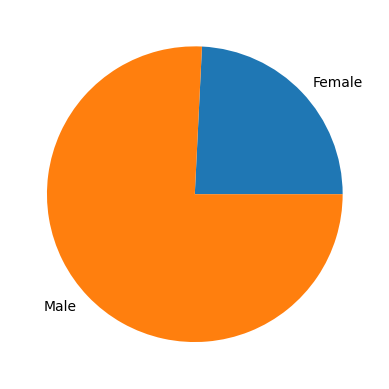

In [373]:
df.groupby('Gender').size().plot(kind='pie')

<Axes: >

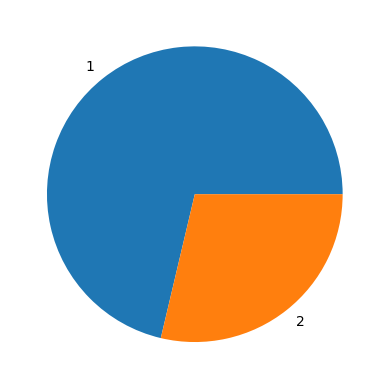

In [374]:
df.groupby('Target').size().plot(kind='pie')

In [376]:
df=pd.get_dummies(df,columns=['Gender'],dtype=int,drop_first=True)
df


,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,Gender_Male
0,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,1
1,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1
2,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,1
3,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1
4,46,1.8,0.7,208,19,14,7.6,4.4,1.30,1,1
...,...,...,...,...,...,...,...,...,...,...,...
577,60,0.5,0.1,500,20,34,5.9,1.6,0.37,2,1
578,40,0.6,0.1,98,35,31,6.0,3.2,1.10,1,1
579,52,0.8,0.2,245,48,49,6.4,3.2,1.00,1,1
580,31,1.3,0.5,184,29,32,6.8,3.4,1.00,1,1


In [377]:
df.rename(columns={'Gender_Male':'Gender'},inplace=True)

In [378]:
df

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,Gender
0,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,1
1,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1
2,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,1
3,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1
4,46,1.8,0.7,208,19,14,7.6,4.4,1.30,1,1
...,...,...,...,...,...,...,...,...,...,...,...
577,60,0.5,0.1,500,20,34,5.9,1.6,0.37,2,1
578,40,0.6,0.1,98,35,31,6.0,3.2,1.10,1,1
579,52,0.8,0.2,245,48,49,6.4,3.2,1.00,1,1
580,31,1.3,0.5,184,29,32,6.8,3.4,1.00,1,1


Gender columns has Male:1  Female:0

Correlation Among Attributes

In [379]:
df.corr(method='pearson')['Target'].sort_values(ascending=False)

Target       1.000
A/G Ratio    0.162
ALB          0.162
TP           0.035
Gender      -0.085
Age         -0.136
Sgot        -0.152
Sgpt        -0.164
Alkphos     -0.185
TB          -0.221
DB          -0.247
Name: Target, dtype: float64

In [380]:
df.skew().sort_values(ascending=False)

Sgot         10.538
Sgpt          6.544
TB            4.903
Alkphos       3.762
DB            3.209
A/G Ratio     0.995
Target        0.944
Age          -0.026
ALB          -0.043
TP           -0.284
Gender       -1.206
dtype: float64

In [381]:
import matplotlib.pyplot as plt

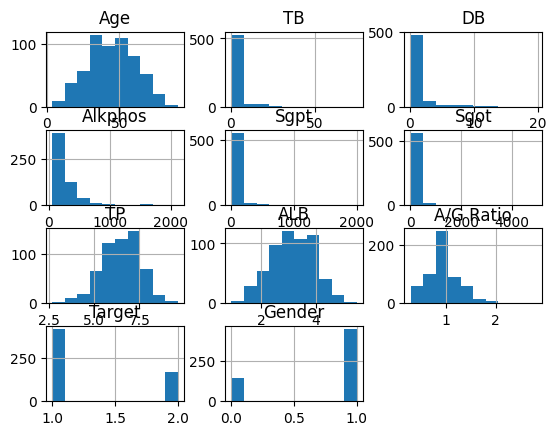

In [382]:
df.hist()
plt.show()

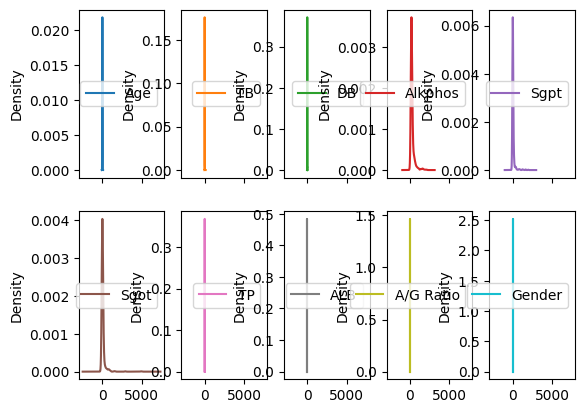

In [383]:
df.drop(columns=['Target']).plot(kind='density',layout=(2,5),subplots=True)
plt.show()

In [384]:
from sklearn import preprocessing

In [385]:
X=df.drop(columns=['Target'])
y=df.Target
scaler=preprocessing.StandardScaler()
rescaledX=scaler.fit_transform(X)
standard_df=pd.DataFrame(rescaledX,columns=X.columns)
standard_df


,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender
0,1.069,1.224,1.429,1.681,-0.092,-0.035,0.937,0.073,-0.650,0.565
1,1.069,0.644,0.930,0.820,-0.114,-0.146,0.477,0.199,-0.179,0.565
2,0.822,-0.371,-0.388,-0.448,-0.366,-0.312,0.292,0.325,0.166,0.565
3,1.688,0.096,0.182,-0.394,-0.295,-0.177,0.753,-0.932,-1.718,0.565
4,0.080,-0.242,-0.281,-0.341,-0.339,-0.333,1.029,1.582,1.108,0.565
...,...,...,...,...,...,...,...,...,...,...
577,0.946,-0.452,-0.494,0.861,-0.333,-0.263,-0.537,-1.938,-1.812,0.565
578,-0.291,-0.435,-0.494,-0.794,-0.251,-0.274,-0.445,0.073,0.480,0.565
579,0.451,-0.403,-0.459,-0.188,-0.180,-0.211,-0.076,0.073,0.166,0.565
580,-0.848,-0.323,-0.352,-0.439,-0.284,-0.270,0.292,0.325,0.166,0.565


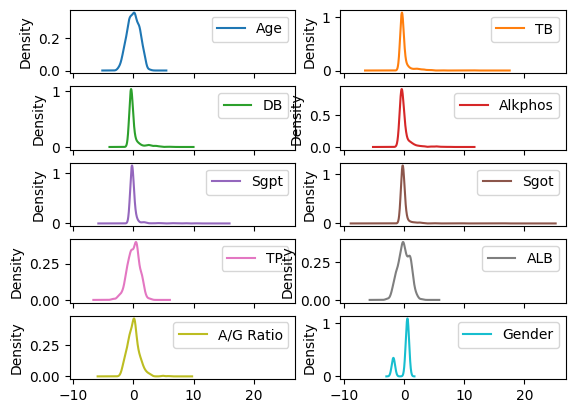

In [386]:
standard_df.plot(kind='density',subplots=True,layout=(5,2))
plt.show()

In [387]:
import sklearn

Age          0.118
Sgot         0.117
Alkphos      0.114
TB           0.113
Sgpt         0.110
DB           0.109
ALB          0.101
A/G Ratio    0.097
TP           0.095
Gender       0.025
dtype: float64


<Axes: >

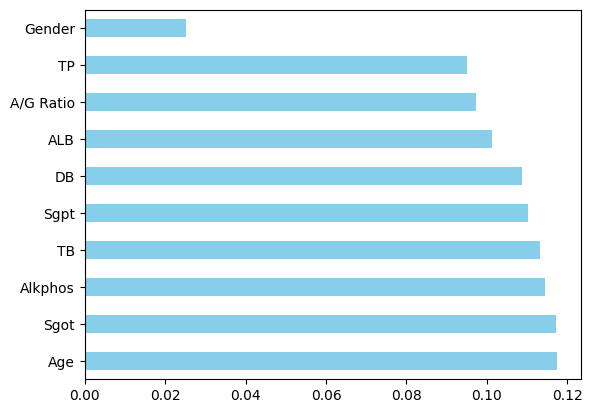

In [388]:
model_feature=sklearn.ensemble.ExtraTreesClassifier()
model_feature.fit(standard_df,y)
feature_imp=pd.Series(model_feature.feature_importances_,index=standard_df.columns)
print(feature_imp.sort_values(ascending=False))
feature_imp.nlargest(10).plot(kind='barh', color='skyblue')

TP has a correlation of 0.035 with the Target Columnn and has a low feature importance Score.

In [389]:
selector = sklearn.feature_selection.SelectFromModel(model_feature, threshold=-float('inf'), max_features=9, prefit=True)

# 3. Create the reduced array
reduced_array_et = selector.transform(standard_df)

# 4. Convert back to DataFrame to see the 9 columns
selected_columns_et = standard_df.columns[selector.get_support()]
new_df_et = pd.DataFrame(reduced_array_et, columns=selected_columns_et)
new_df_et

c:\Users\aadya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
0,1.069,1.224,1.429,1.681,-0.092,-0.035,0.937,0.073,-0.650
1,1.069,0.644,0.930,0.820,-0.114,-0.146,0.477,0.199,-0.179
2,0.822,-0.371,-0.388,-0.448,-0.366,-0.312,0.292,0.325,0.166
3,1.688,0.096,0.182,-0.394,-0.295,-0.177,0.753,-0.932,-1.718
4,0.080,-0.242,-0.281,-0.341,-0.339,-0.333,1.029,1.582,1.108
...,...,...,...,...,...,...,...,...,...
577,0.946,-0.452,-0.494,0.861,-0.333,-0.263,-0.537,-1.938,-1.812
578,-0.291,-0.435,-0.494,-0.794,-0.251,-0.274,-0.445,0.073,0.480
579,0.451,-0.403,-0.459,-0.188,-0.180,-0.211,-0.076,0.073,0.166
580,-0.848,-0.323,-0.352,-0.439,-0.284,-0.270,0.292,0.325,0.166


In [390]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

#Fit the Model

test = SelectKBest(score_func=f_classif, k=9)
fit = test.fit(standard_df, y)

#View The Scores after the statistical test was made to fit our dataset
df_scores = pd.DataFrame(fit.scores_, index=standard_df.columns, columns=['Score'])
df_scores = df_scores.sort_values(by='Score', ascending=False)
print(df_scores)


            Score
DB         37.594
TB         29.718
Alkphos    20.651
Sgpt       16.006
A/G Ratio  15.661
ALB        15.566
Sgot       13.781
Age        10.966
Gender      4.180
TP          0.725


In [391]:
model=sklearn.linear_model.LogisticRegression()
kfold=sklearn.model_selection.KFold(n_splits=10,random_state=7,shuffle=True)
results=sklearn.model_selection.cross_val_score(model,standard_df,y,cv=kfold)
print(results.mean())


0.7180596142606663


In [392]:
# 1. Initialize LDA
model_lda = sklearn.discriminant_analysis.LinearDiscriminantAnalysis()

# 2. Use the same K-Fold and X, Y
results_lda = sklearn.model_selection.cross_val_score(model_lda, standard_df,y, cv=kfold)

# 3. Print the result
print(f"LDA Accuracy: {results_lda.mean():.4f}")

LDA Accuracy: 0.7061


In [393]:
# 1. Initialize Random Forest
model_random = sklearn.ensemble.RandomForestClassifier()

# 2. Use the same K-Fold and X, Y
results_random = sklearn.model_selection.cross_val_score(model_random, standard_df,y, cv=kfold,scoring='accuracy')

# 3. Print the result
print(f"Random Forest Accuracy: {results_random.mean():.4f}")

Random Forest Accuracy: 0.6940


In [394]:
# 1. Initialize Extra Trees Classifier
model_trees = sklearn.ensemble.ExtraTreesClassifier(n_estimators=100, random_state=7)
# 2. Use the same K-Fold and X, Y
results_1= sklearn.model_selection.cross_val_score(model_trees, standard_df,y, cv=kfold,scoring='accuracy')

# 3. Print the result
print(f"Extra Trees Classifier Accuracy: {results_1.mean():.4f}")

Extra Trees Classifier Accuracy: 0.7422


In [396]:
from pickle import dump
from pickle import load

In [399]:
model_trees.fit(standard_df, y)

# 3. Define the filename and save the model
# 'wb' means Write Binary, which is required for saving models
filename = 'liver_model_final.sav'
dump(model_trees, open(filename, 'wb'))

In [402]:
loaded_model = load(open(filename, 'rb'))

# 5. Check the accuracy on your test set to verify it loaded correctly
# Note: X_test must have the exact same 10 columns as standard_df
result = loaded_model.score(standard_df,y)

print(f"Loaded Model Accuracy: {result * 100:.2f}%")

Loaded Model Accuracy: 100.00%


ModuleNotFoundError: No module named 'gradio'